All Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from keras.src.optimizers import optimizer
import keras_tuner as kt

Make a Lorentz dataset using RK4 method

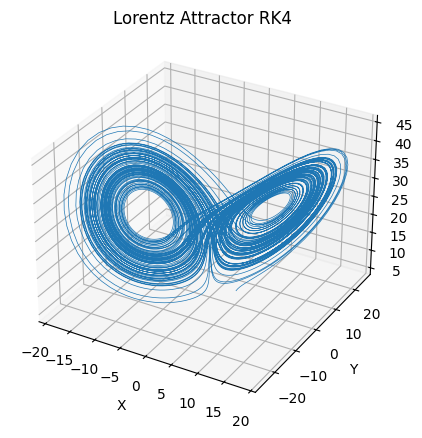

In [2]:
def generate_lorentz_data(initial):

  # Lorentz parameters
  sigma = 10
  rho = 28
  beta = 8/3

  # Lorentz system
  def lorentz(x, y, z):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

  # RK4 step
  def rk4_step(state, dt):
    k1 = lorentz(*state)
    k2 = lorentz(*(state + dt * k1 / 2))
    k3 = lorentz(*(state + dt * k2 / 2))
    k4 = lorentz(*(state + dt * k3))

    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

  # Simulation parameters
  dt = 0.01
  steps = 10000

  # Initial condition
  state = initial

  trajectory = np.zeros((steps, 3))
  trajectory[0] = state

  for i in range(1,steps):
    state = rk4_step(state, dt)
    trajectory[i] = state

  return trajectory


# Plot function
def plot_data(trajectory,title='RK4'):

  fig = plt.figure(figsize=(7, 5))
  ax = fig.add_subplot(111, projection='3d')

  ax.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2], lw=0.5)

  ax.set_xlabel("X")
  ax.set_ylabel("Y")
  ax.set_zlabel("Z")
  ax.set_title("Lorentz Attractor "+title)

  plt.show()

pt1 = np.array([1.0, 1.0, 1.0])
pt2 = np.array([4.0, 3.0, 5.0])

dataset1 = generate_lorentz_data(pt1)
dataset2 = generate_lorentz_data(pt2)

plot_data(dataset2)

Make Trainable dataset

In [4]:
X1 = dataset1[:-1]
y1 = dataset1[1:]
X2 = dataset2[:-1]
y2 = dataset2[1:]

X = np.vstack((X1,X2))
y = np.vstack((y1,y2))

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=1)
print(X_train.shape, y_test.shape)

(17998, 3) (2000, 3)


Finding Data ranges

In [5]:
all_data = np.vstack([X, y])
# Taking a +50% margin
data_min = all_data.min(axis=0) * (1.5)
data_max = all_data.max(axis=0) * (1.5)
print(f"  Data min: {data_min}")
print(f"  Data max: {data_max}")

data_range = data_max - data_min
print(f" Data range: {data_range}")

  Data min: [-27.90481251 -37.96102466   1.44260584]
  Data max: [29.33256101 40.7752097  71.75093113]
 Data range: [57.23737352 78.73623437 70.3083253 ]


Applying MinMaxScaling

In [6]:
def MinMaxScaling(values, min_data = data_min, range = data_range):
  return (values - min_data)/range

def MinMaxRescaling(values, min_data = data_min, range = data_range):
  return (values * range)+min_data

X_train_Scaled = MinMaxScaling(X_train)
y_train_Scaled = MinMaxScaling(y_train)

X_test_Scaled = MinMaxScaling(X_test)
y_test_Scaled = MinMaxScaling(y_test)

Take suitable parameters for the model (Keras tuner)

In [7]:
def make_model(mdl):

  model = Sequential()

  counter = 0

  for i in range(mdl.Int('num_layers', min_value = 1, max_value = 1)):

    if counter == 0:

      model.add(
        Dense(
          mdl.Int('units'+str(i), min_value = 1, max_value = 8),
          activation= mdl.Choice('activation'+str(i), values=['relu','linear']),
          input_dim = 3
        )
      )

    else:

      model.add(
        Dense(
          mdl.Int('units'+str(i), min_value = 1, max_value = 8),
          activation= mdl.Choice('activation'+str(i), values=['relu','linear']),
        )
      )

    counter += 1

  model.add(Dense(3,activation= mdl.Choice('activation', values=['relu','linear'])))

  model.compile(optimizer='nadam',loss='mse')
  return model

Make the Keras Tuner Object

In [8]:
tuner = kt.RandomSearch(make_model, objective='val_loss', max_trials=25, directory='mydir', project_name='trial22')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Get best Hyperparameters

In [9]:
tuner.search(X_train_Scaled,y_train_Scaled,epochs=15,validation_data=([X_test_Scaled,y_test_Scaled]))

Trial 25 Complete [00h 00m 29s]
val_loss: 5.4214662668528035e-05

Best val_loss So Far: 5.4040974646341056e-05
Total elapsed time: 00h 11m 35s


Build Model

In [20]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Get the model architecture

In [21]:
for layer in model.layers:
    print(f"Layer: {layer.name}, Activation: {layer.activation.__name__}")

Layer: dense, Activation: linear
Layer: dense_1, Activation: relu


Get Model Summary

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 38 (152.00 B)

 Non-trainable params: 0 (0.00 B)

Train Model

In [23]:
model.fit(X_train_Scaled,y_train_Scaled,epochs=40,validation_data=(X_test_Scaled,y_test_Scaled))

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.2852e-05 - val_loss: 5.6183e-05
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2829e-05 - val_loss: 5.7585e-05
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2757e-05 - val_loss: 5.5639e-05
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2745e-05 - val_loss: 5.7043e-05
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2685e-05 - val_loss: 5.4249e-05
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.2601e-05 - val_loss: 6.0308e-05
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.2775e-05 - val_loss: 6.0336e-05
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2835e-05 - val_loss: 5.5142e-05
Epoch 9/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2730e-05 - val_loss: 5.6520e-05
Epoch 10/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2711e-05 - val_loss: 5.6451e-05
Epoch 11/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss

Test for a new dataset (Prediction data)

In [ ]:
new_data = generate_lorentz_data(np.array([1.0,1.0,1.0]))
new_X = new_data[:-1]
new_y = new_data[1:]
y_pred = []

X_sim = MinMaxScaling(new_X)
y_pred_sim = model.predict(X_sim)
y_pred = MinMaxRescaling(y_pred_sim)

print(len(y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
9999


Visualize predicted data

MSE: 0.2650736036562463


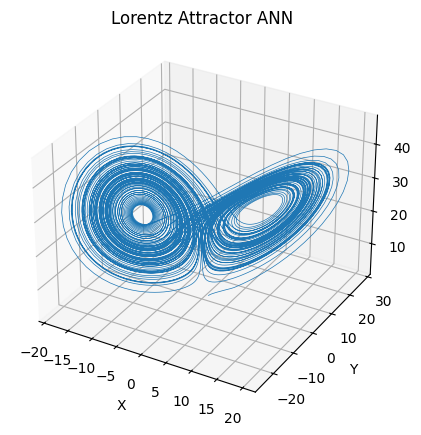

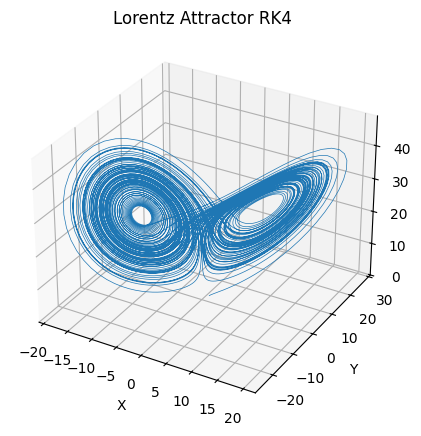

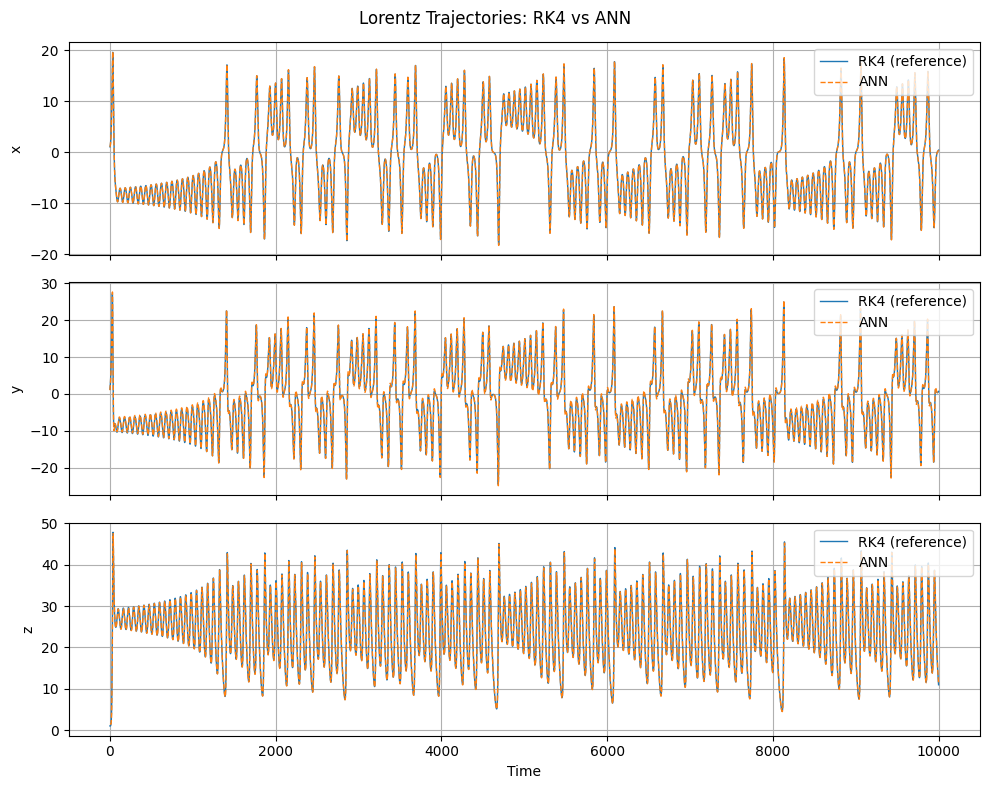

In [51]:
mse_value = mean_squared_error(new_y, y_pred)
print(f"MSE: {mse_value}")

plot_data(y_pred,'ANN')
plot_data(new_y)

def compare_trajectories(y_pred,new_y):

  x = new_y[:,0]
  y = new_y[:,1]
  z = new_y[:,2]

  x_model = y_pred[:,0]
  y_model = y_pred[:,1]
  z_model = y_pred[:,2]

  t = np.zeros(len(x))
  for i in range (len(x)): t[i] = i

  fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

  plt.subplot(3,1,1)
  plt.plot(t, x, label='RK4 (reference)', linewidth=1)
  plt.plot(t, x_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('x')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,2)
  plt.plot(t, y, label='RK4 (reference)', linewidth=1)
  plt.plot(t, y_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('y')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,3)
  plt.plot(t, z, label='RK4 (reference)', linewidth=1)
  plt.plot(t, z_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('z')
  plt.grid(True)
  plt.legend(loc='upper right')

  axs[-1].set_xlabel('Time')
  fig.suptitle('Lorentz Trajectories: RK4 vs ANN')
  plt.tight_layout()
  plt.show()

compare_trajectories(y_pred,new_y)

In [52]:
all_weights = []
all_biases = []

for layer in model.layers:
    weights = layer.get_weights()
    w, b = weights
    all_weights.append(w)
    all_biases.append(b)

W1 = all_weights[0]   # (4,3)
b1 = all_biases[0]     # (3,)
W2 = all_weights[1]   # (3,4)
b2 = all_biases[1]     # (4,)

print(W1)
print(W2)
print(b1)
print(b2)

[[ 0.7656652   0.25723004  0.5921791   0.3966764   0.54353523]
 [ 0.86023164 -0.02144163  0.88325626 -0.37304467 -0.39079222]
 [ 0.4781371  -0.837726   -0.443007    0.27515227  0.4422307 ]]
[[ 0.13991088  0.49728134  0.10541594]
 [ 0.33246517 -0.3429143  -0.9391943 ]
 [ 0.39888367  0.26035437 -0.01890596]
 [-0.10712904 -0.46909237 -0.27315766]
 [ 0.94409233 -0.6358598   0.510702  ]]
[-0.106125   -0.0163231  -0.257821   -0.10771223  0.04670038]
[ 0.05055358  0.09251972 -0.05998832]


Trying a NEW Model

In [7]:
all_data = np.vstack([X, y])
# Taking a +20% margin
new_data_min = all_data.min(axis=0) * (1.2)
new_data_max = all_data.max(axis=0) * (1.2)
print(f"  Data min: {new_data_min}")
print(f"  Data max: {new_data_max}")

new_data_range = new_data_max - new_data_min
print(f" Data range: {new_data_range}")

  Data min: [-22.32385001 -30.36881973   1.15408467]
  Data max: [23.46604881 32.62016776 57.40074491]
 Data range: [45.78989882 62.98898749 56.24666024]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MSE: 0.08743704689637864


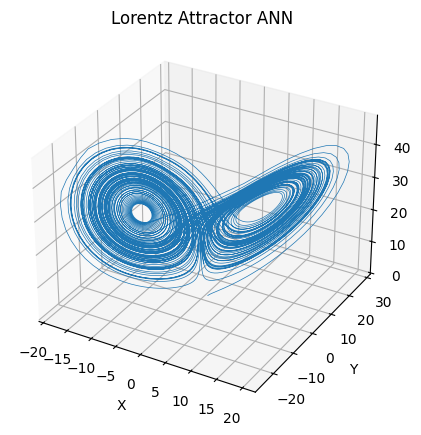

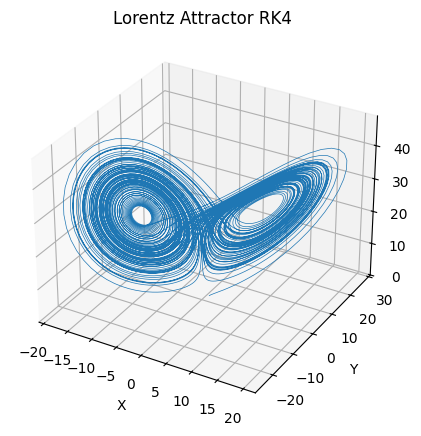

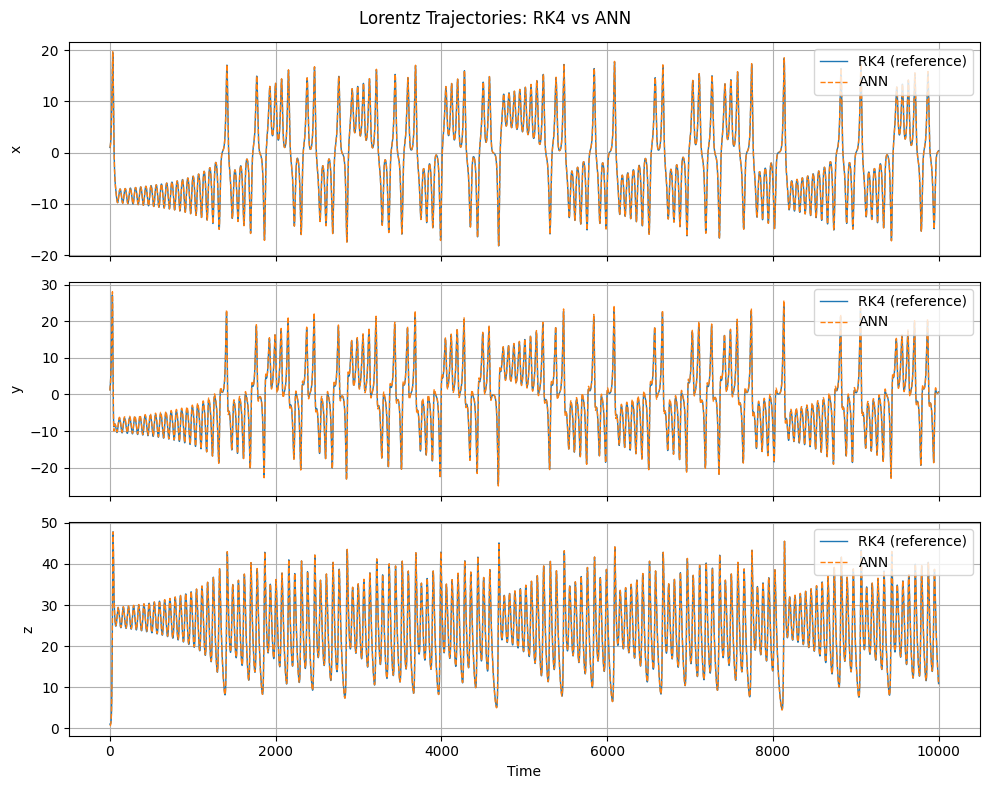

In [17]:
new_data = generate_lorentz_data(np.array([1.0,1.0,1.0]))
new_X = new_data[:-1]
new_y = new_data[1:]
y_pred = []

os.chdir("E:\\Python n Verilog\\Lorentz 2 and Encryption\\Some pretrained models")
new_model = tf.keras.models.load_model("lorentz_model.keras")

X_sim = MinMaxScaling(new_X, min_data= new_data_min ,range = new_data_range)
y_pred_sim = new_model.predict(X_sim)
y_pred = MinMaxRescaling(y_pred_sim, min_data= new_data_min ,range = new_data_range)

mse_value = mean_squared_error(new_y, y_pred)
print(f"MSE: {mse_value}")

plot_data(y_pred,'ANN')
plot_data(new_y)

def compare_trajectories(y_pred,new_y):

  x = new_y[:,0]
  y = new_y[:,1]
  z = new_y[:,2]

  x_model = y_pred[:,0]
  y_model = y_pred[:,1]
  z_model = y_pred[:,2]

  t = np.zeros(len(x))
  for i in range (len(x)): t[i] = i

  fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

  plt.subplot(3,1,1)
  plt.plot(t, x, label='RK4 (reference)', linewidth=1)
  plt.plot(t, x_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('x')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,2)
  plt.plot(t, y, label='RK4 (reference)', linewidth=1)
  plt.plot(t, y_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('y')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,3)
  plt.plot(t, z, label='RK4 (reference)', linewidth=1)
  plt.plot(t, z_model, linestyle='--', label='ANN', linewidth=1)
  plt.ylabel('z')
  plt.grid(True)
  plt.legend(loc='upper right')

  axs[-1].set_xlabel('Time')
  fig.suptitle('Lorentz Trajectories: RK4 vs ANN')
  plt.tight_layout()
  plt.show()

compare_trajectories(y_pred,new_y)

Get better performing weights

In [11]:
all_weights = []
all_biases = []

for layer in new_model.layers:
    weights = layer.get_weights()
    w, b = weights
    all_weights.append(w)
    all_biases.append(b)

W1 = all_weights[0]   # (4,3)
b1 = all_biases[0]     # (3,)
W2 = all_weights[1]   # (3,4)
b2 = all_biases[1]     # (4,)

print(W1)
print(W2)
print(b1)
print(b2)

[[-0.46098718  1.2967374  -0.53748846  0.15106906  0.15356664]
 [-0.59097326  0.4566736   1.1430912   0.93308777  0.4572297 ]
 [-0.46240565 -0.42452806  0.02058134  0.00831485  0.83449566]]
[[ 0.47926575  0.42978626 -0.09506387]
 [ 0.5659336   0.25614476 -0.30757475]
 [-0.2228698   0.811726   -0.40178004]
 [ 0.00115834  0.00725291  0.27457404]
 [ 0.29331294  0.10943781  1.0312512 ]]
[ 0.          0.07673879 -0.0238655  -0.5196164  -0.03752615]
[-0.05484406  0.00189161  0.1145853 ]
